# Class Activity: Multiple Linear Regression -- Fuel Consumption & CO2 Emissions

## Objective

In Session 1, we predicted CO2 emissions using a **single feature** (Engine Size). In this activity, you will explore whether using **multiple features** improves predictions.

## What You Will Do

| Part | Task |
|------|------|
| 1 | Explore the dataset and identify candidate features |
| 2 | Build a single-feature baseline model |
| 3 | Build a multiple-feature model and compare |
| 4 | Investigate feature contributions |
| 5 | Challenge: Find the best feature combination |

**Dataset:** `FuelConsumptionCo2.csv`  
**Target variable:** `CO2EMISSIONS`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 300
sns.set_style('whitegrid')
np.random.seed(42)

---
## Part 1: Explore the Dataset

Before building any model, we need to understand what features are available and how they relate to our target.

In [2]:
# Load the dataset
fuel_df = pd.read_csv('../../../Datasets/FuelConsumptionCo2.csv')

print(f'Dataset shape: {fuel_df.shape}')

print(f'\nColumns:')
for col in fuel_df.columns:
    print(f'  {col} ({fuel_df[col].dtype})')

fuel_df.head()

Dataset shape: (1067, 13)

Columns:
  MODELYEAR (int64)
  MAKE (object)
  MODEL (object)
  VEHICLECLASS (object)
  ENGINESIZE (float64)
  CYLINDERS (int64)
  TRANSMISSION (object)
  FUELTYPE (object)
  FUELCONSUMPTION_CITY (float64)
  FUELCONSUMPTION_HWY (float64)
  FUELCONSUMPTION_COMB (float64)
  FUELCONSUMPTION_COMB_MPG (int64)
  CO2EMISSIONS (int64)


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
# Statistical summary of numeric columns
fuel_df.describe().round(2)

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.00,1067.00,1067.00,1067.00,1067.00,1067.00,1067.00
mean,2014.0,3.35,5.79,13.30,9.47,11.58,26.44,256.23
std,0.0,1.42,1.80,4.10,2.79,3.49,7.47,63.37
min,2014.0,1.00,3.00,4.60,4.90,4.70,11.00,108.00
25%,2014.0,2.00,4.00,10.25,7.50,9.00,21.00,207.00
50%,2014.0,3.40,6.00,12.60,8.80,10.90,26.00,251.00
75%,2014.0,4.30,8.00,15.55,10.85,13.35,31.00,294.00
max,2014.0,8.40,12.00,30.20,20.50,25.80,60.00,488.00


### Task 1a: Correlation Analysis

Which numeric features are most strongly correlated with `CO2EMISSIONS`? Let's find out.

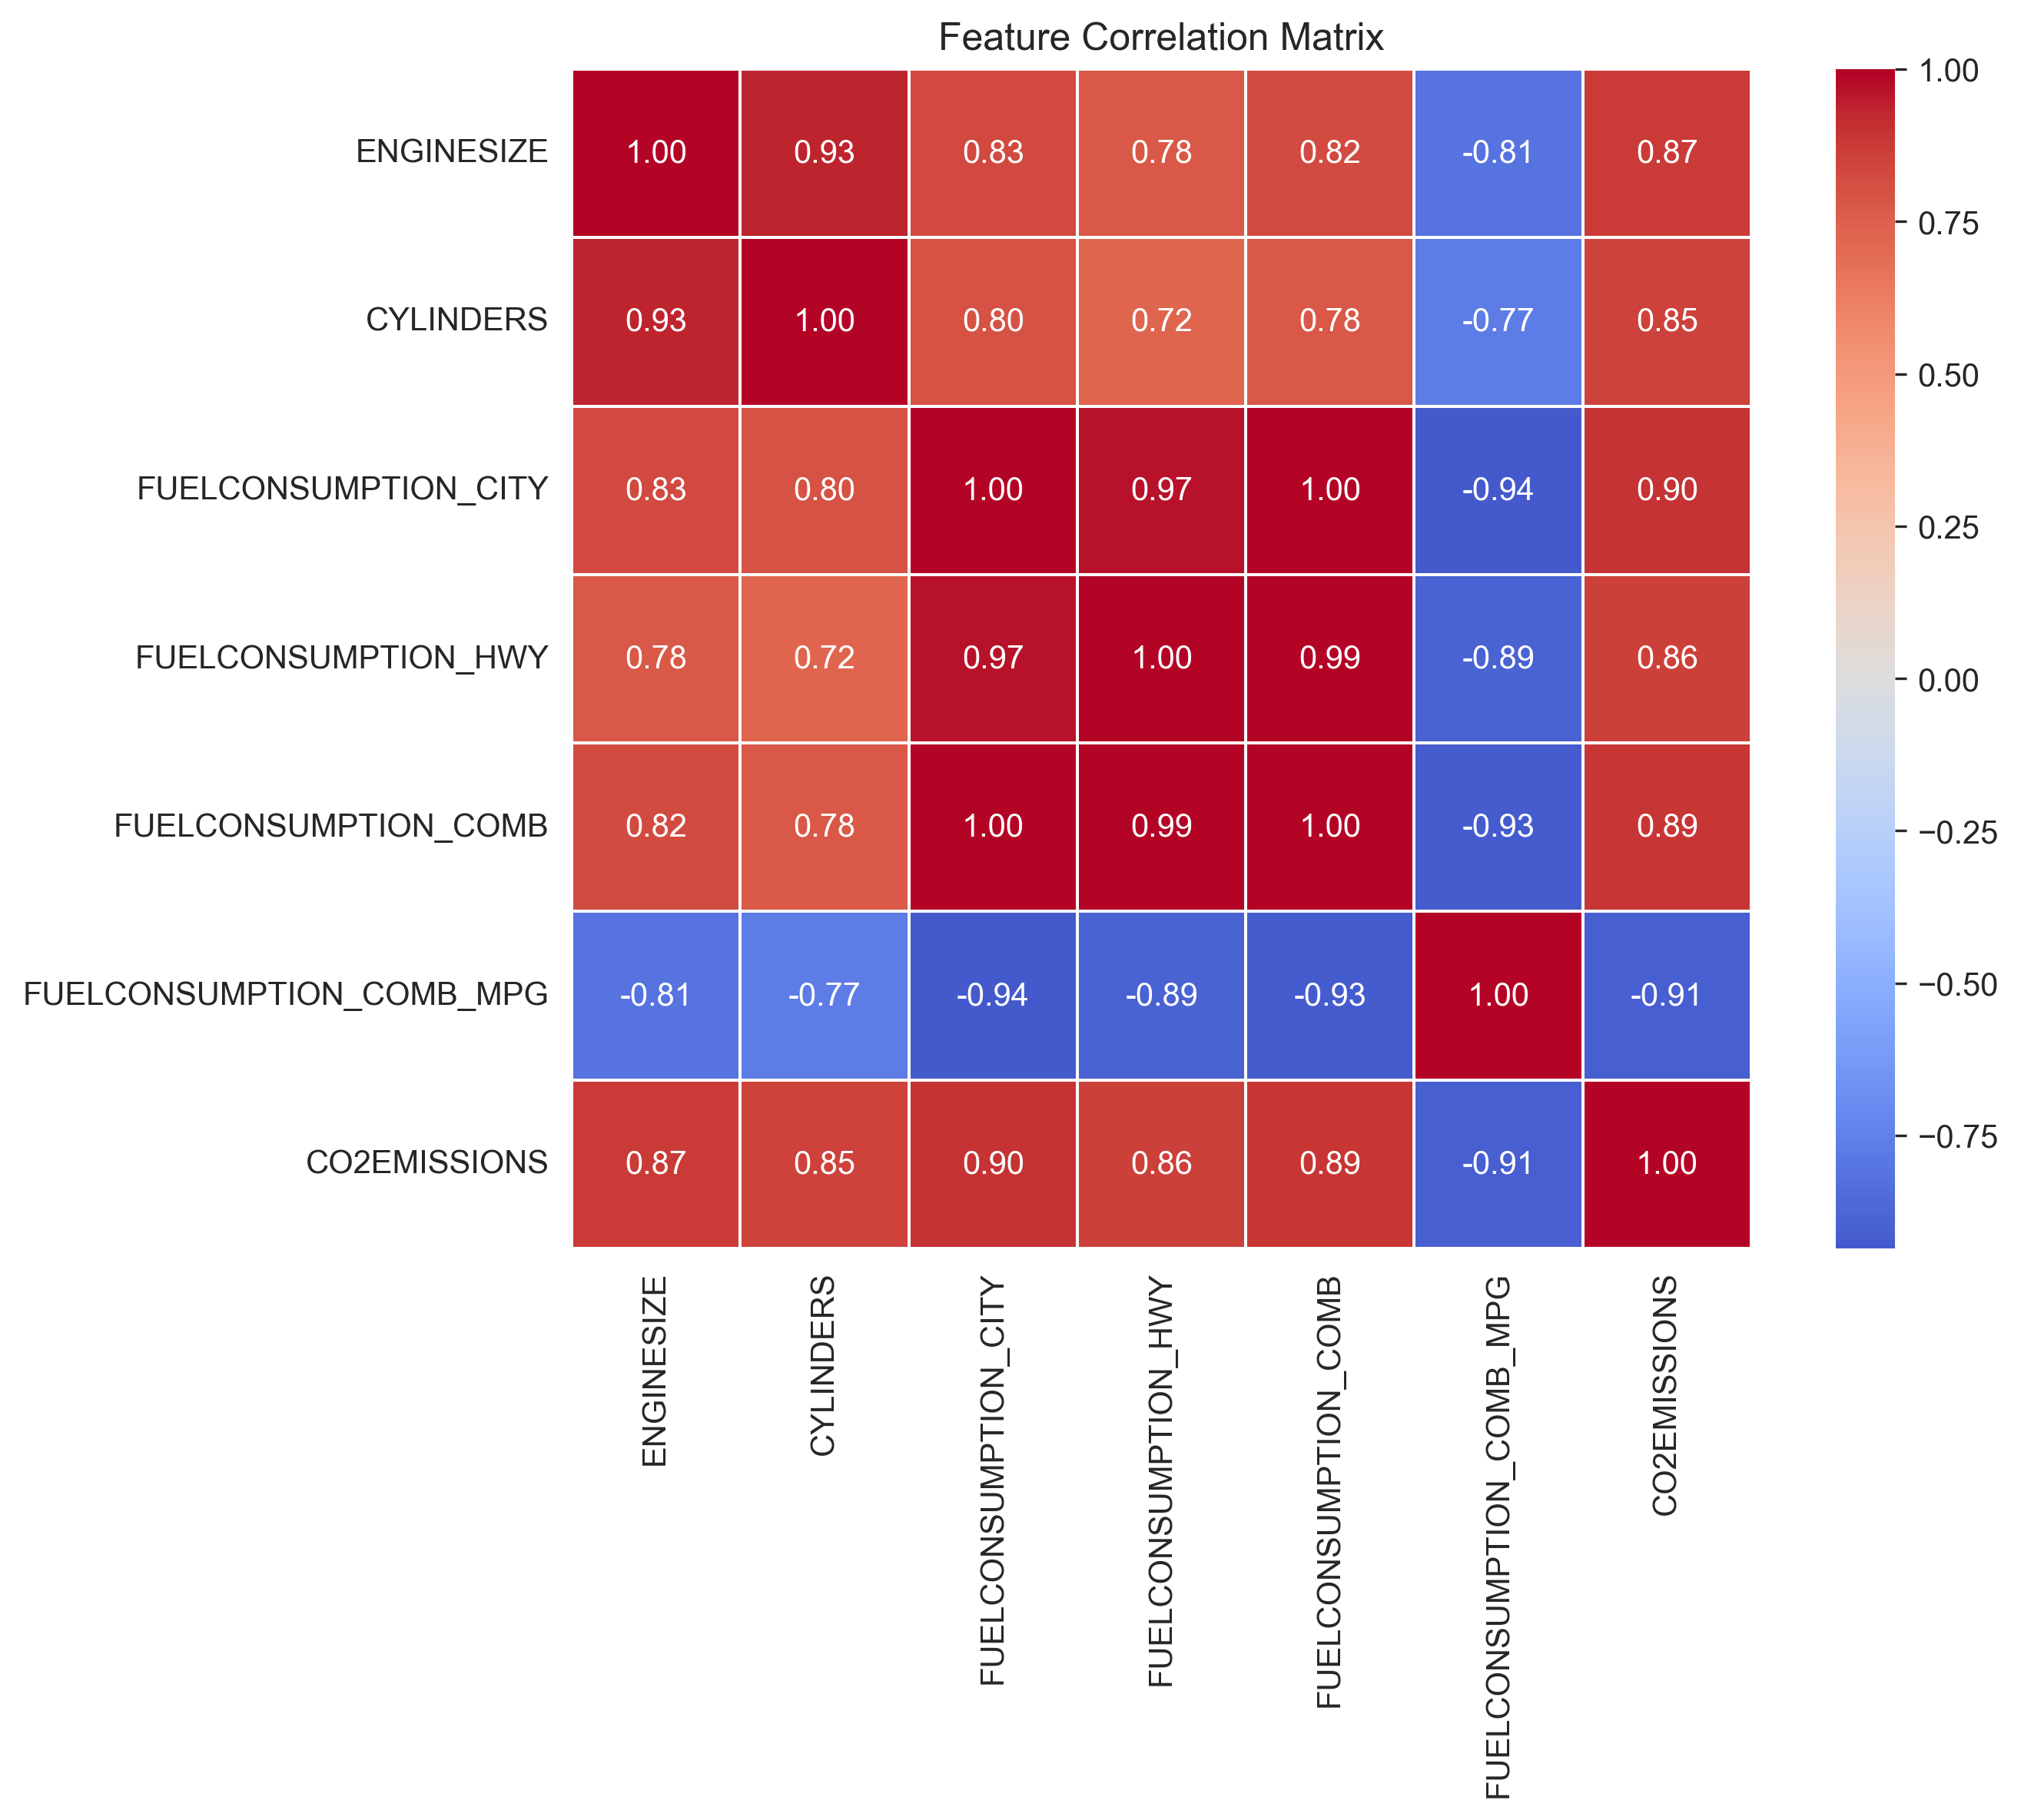

In [4]:
# Select only the numeric columns relevant for prediction
numeric_features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY',
                     'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
                     'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = fuel_df[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [5]:
# Rank features by correlation with CO2EMISSIONS
co2_corr = corr['CO2EMISSIONS'].drop('CO2EMISSIONS').abs().sort_values(ascending=False)
print('Feature correlations with CO2EMISSIONS (absolute value):\n')
for feature, value in co2_corr.items():
    print(f'  {feature:30s} {value:.4f}')

Feature correlations with CO2EMISSIONS (absolute value):

  FUELCONSUMPTION_COMB_MPG       0.9064
  FUELCONSUMPTION_CITY           0.8980
  FUELCONSUMPTION_COMB           0.8921
  ENGINESIZE                     0.8742
  FUELCONSUMPTION_HWY            0.8617
  CYLINDERS                      0.8497


### Discussion Questions (Part 1)

1. Which feature has the **strongest** correlation with CO2 emissions?
2. Which features are **highly correlated with each other**? Why might this be a problem?
3. What does the **negative** correlation of `FUELCONSUMPTION_COMB_MPG` mean?

---
## Part 2: Single-Feature Baseline Model

First, let's establish a baseline using just one feature, so we can measure how much improvement multiple features give us.

In [6]:
# Baseline: predict CO2 from ENGINESIZE only
X_baseline = fuel_df[['ENGINESIZE']]
y = fuel_df['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(X_baseline, y, test_size=0.2, random_state=42)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

baseline_r2 = r2_score(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print('=== BASELINE MODEL (ENGINESIZE only) ===')
print(f'  R-squared: {baseline_r2:.4f} ({baseline_r2*100:.1f}% variance explained)')
print(f'  RMSE:      {baseline_rmse:.2f} g/km')
print(f'  Equation:  CO2 = {baseline_model.coef_[0]:.2f} x EngineSize + {baseline_model.intercept_:.2f}')

=== BASELINE MODEL (ENGINESIZE only) ===
  R-squared: 0.7616 (76.2% variance explained)
  RMSE:      31.40 g/km
  Equation:  CO2 = 38.99 x EngineSize + 126.29


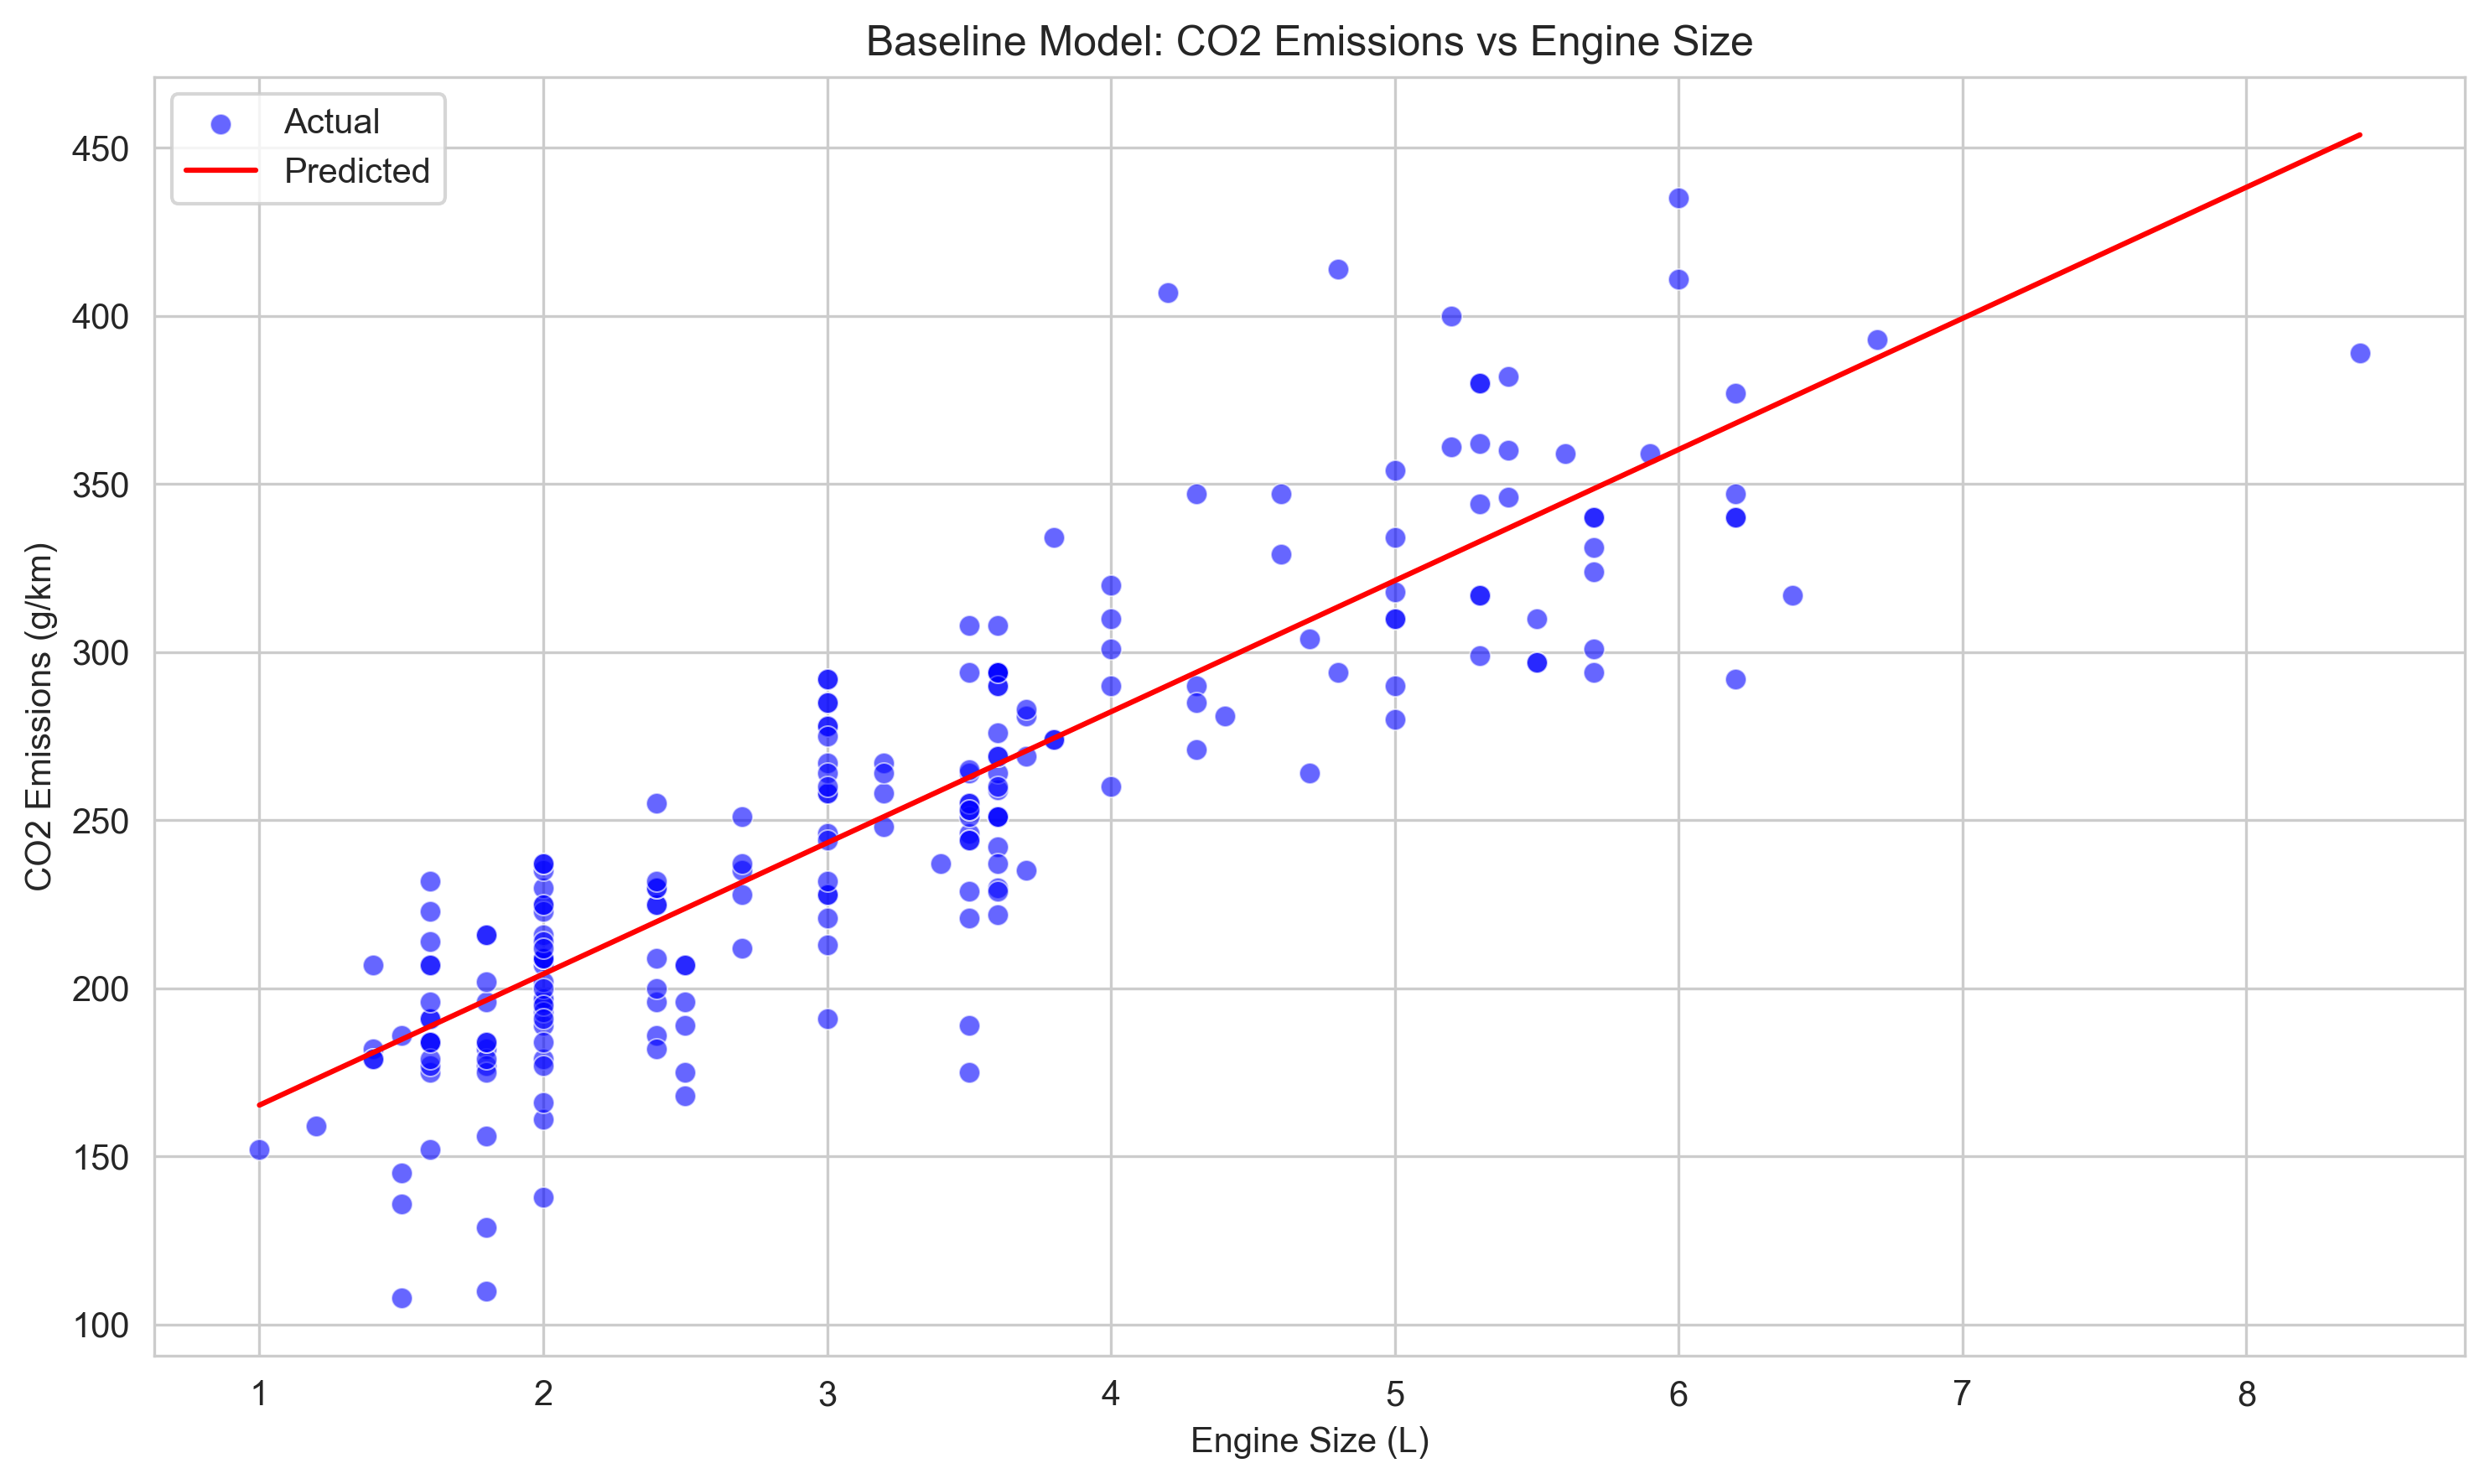

In [16]:
# Add visualization of baseline predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['ENGINESIZE'], y=y_test, label='Actual', color='blue', alpha=0.6)
sns.lineplot(x=X_test['ENGINESIZE'], y=y_pred_baseline, label='Predicted', color='red')
plt.title('Baseline Model: CO2 Emissions vs Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.legend()
plt.tight_layout()
plt.show() 

---
## Part 3: Multiple-Feature Model

Now let's use multiple features. We'll start with features that represent different aspects of the vehicle:
- `ENGINESIZE` -- engine displacement
- `CYLINDERS` -- number of cylinders
- `FUELCONSUMPTION_CITY` -- fuel consumption in the city (L/100km)
- `FUELCONSUMPTION_HWY` -- fuel consumption on the highway (L/100km)

In [7]:
# Multiple feature model
features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY']

X_multi = fuel_df[features]
y = fuel_df['CO2EMISSIONS']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)
y_pred_multi = multi_model.predict(X_test_m)

multi_r2 = r2_score(y_test_m, y_pred_multi)
multi_rmse = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))

print('=== MULTIPLE FEATURE MODEL ===')
print(f'  Features: {features}')
print(f'  R-squared: {multi_r2:.4f} ({multi_r2*100:.1f}% variance explained)')
print(f'  RMSE:      {multi_rmse:.2f} g/km')
print(f'\n  Improvement over baseline:')
print(f'    R-squared: +{(multi_r2 - baseline_r2)*100:.2f} percentage points')
print(f'    RMSE:      {baseline_rmse - multi_rmse:.2f} g/km reduction')

=== MULTIPLE FEATURE MODEL ===
  Features: ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY']
  R-squared: 0.8763 (87.6% variance explained)
  RMSE:      22.62 g/km

  Improvement over baseline:
    R-squared: +11.47 percentage points
    RMSE:      8.78 g/km reduction


### Visualize: Baseline vs Multiple Features

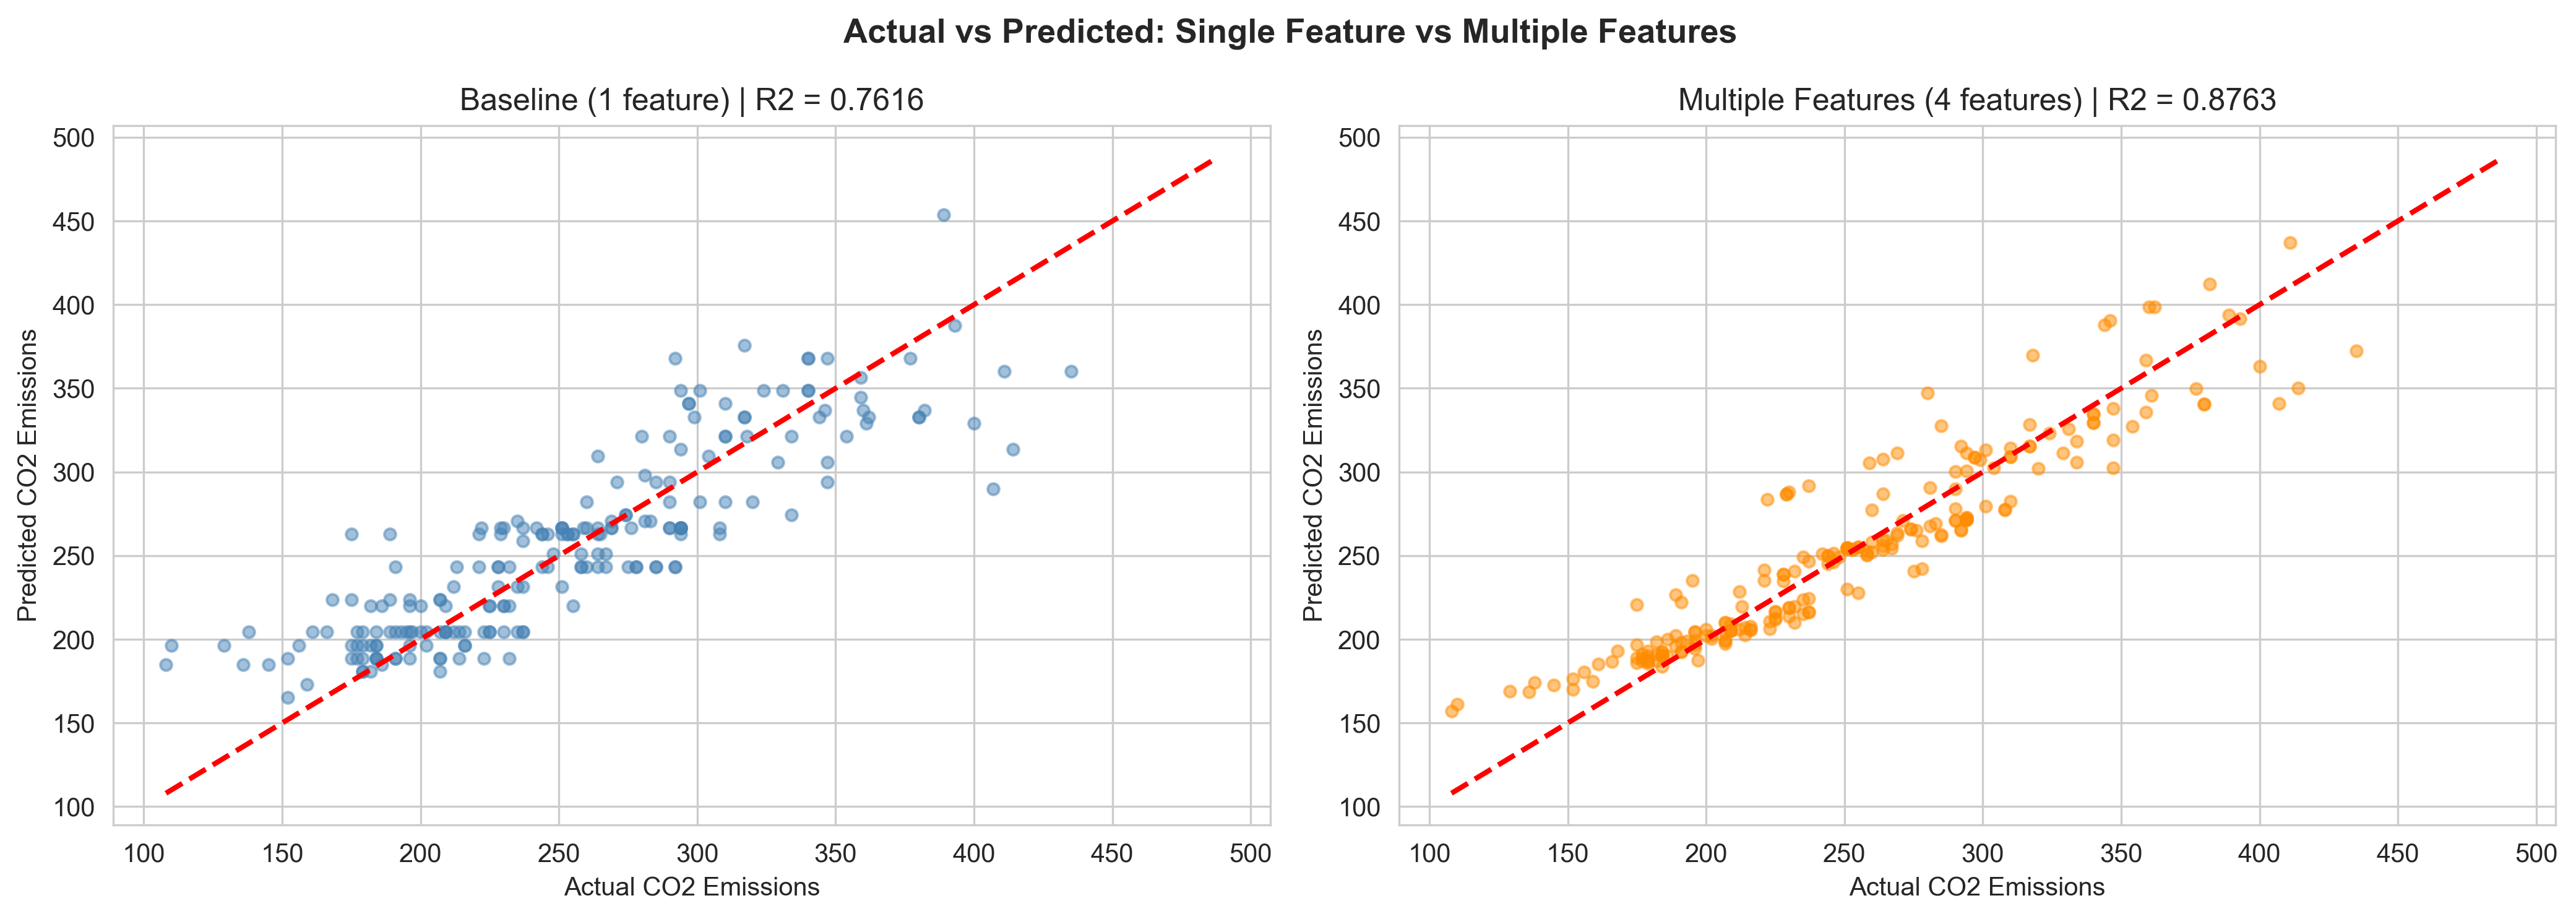

Notice how the points cluster more tightly around the red line with multiple features.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline: Actual vs Predicted
axes[0].scatter(y_test, y_pred_baseline, alpha=0.5, s=20, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual CO2 Emissions')
axes[0].set_ylabel('Predicted CO2 Emissions')
axes[0].set_title(f'Baseline (1 feature) | R2 = {baseline_r2:.4f}')

# Multi: Actual vs Predicted
axes[1].scatter(y_test_m, y_pred_multi, alpha=0.5, s=20, color='darkorange')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual CO2 Emissions')
axes[1].set_ylabel('Predicted CO2 Emissions')
axes[1].set_title(f'Multiple Features (4 features) | R2 = {multi_r2:.4f}')

plt.suptitle('Actual vs Predicted: Single Feature vs Multiple Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Notice how the points cluster more tightly around the red line with multiple features.')

---
## Part 4: Investigate Feature Contributions

Not all features contribute equally to the prediction. Let's examine the model coefficients to understand each feature's role.

In [9]:
# Display coefficients
print('Model equation:')
equation = f'  CO2 = {multi_model.intercept_:.2f}'
for feature, coef in zip(features, multi_model.coef_):
    sign = '+' if coef >= 0 else '-'
    equation += f' {sign} {abs(coef):.4f} x {feature}'
print(equation)

print('\nCoefficient interpretation:')
for feature, coef in zip(features, multi_model.coef_):
    print(f'  {feature:25s}: {coef:+.4f}  (1 unit increase -> {coef:+.2f} g/km CO2)')

Model equation:
  CO2 = 67.83 + 11.2357 x ENGINESIZE + 7.0089 x CYLINDERS + 5.5960 x FUELCONSUMPTION_CITY + 3.8139 x FUELCONSUMPTION_HWY

Coefficient interpretation:
  ENGINESIZE               : +11.2357  (1 unit increase -> +11.24 g/km CO2)
  CYLINDERS                : +7.0089  (1 unit increase -> +7.01 g/km CO2)
  FUELCONSUMPTION_CITY     : +5.5960  (1 unit increase -> +5.60 g/km CO2)
  FUELCONSUMPTION_HWY      : +3.8139  (1 unit increase -> +3.81 g/km CO2)


### Why Raw Coefficients Can Be Misleading

Features have **different scales**. `ENGINESIZE` ranges from ~1 to 8, while `FUELCONSUMPTION_CITY` ranges from ~4 to 30. To fairly compare feature importance, we need to **standardize** the features first.

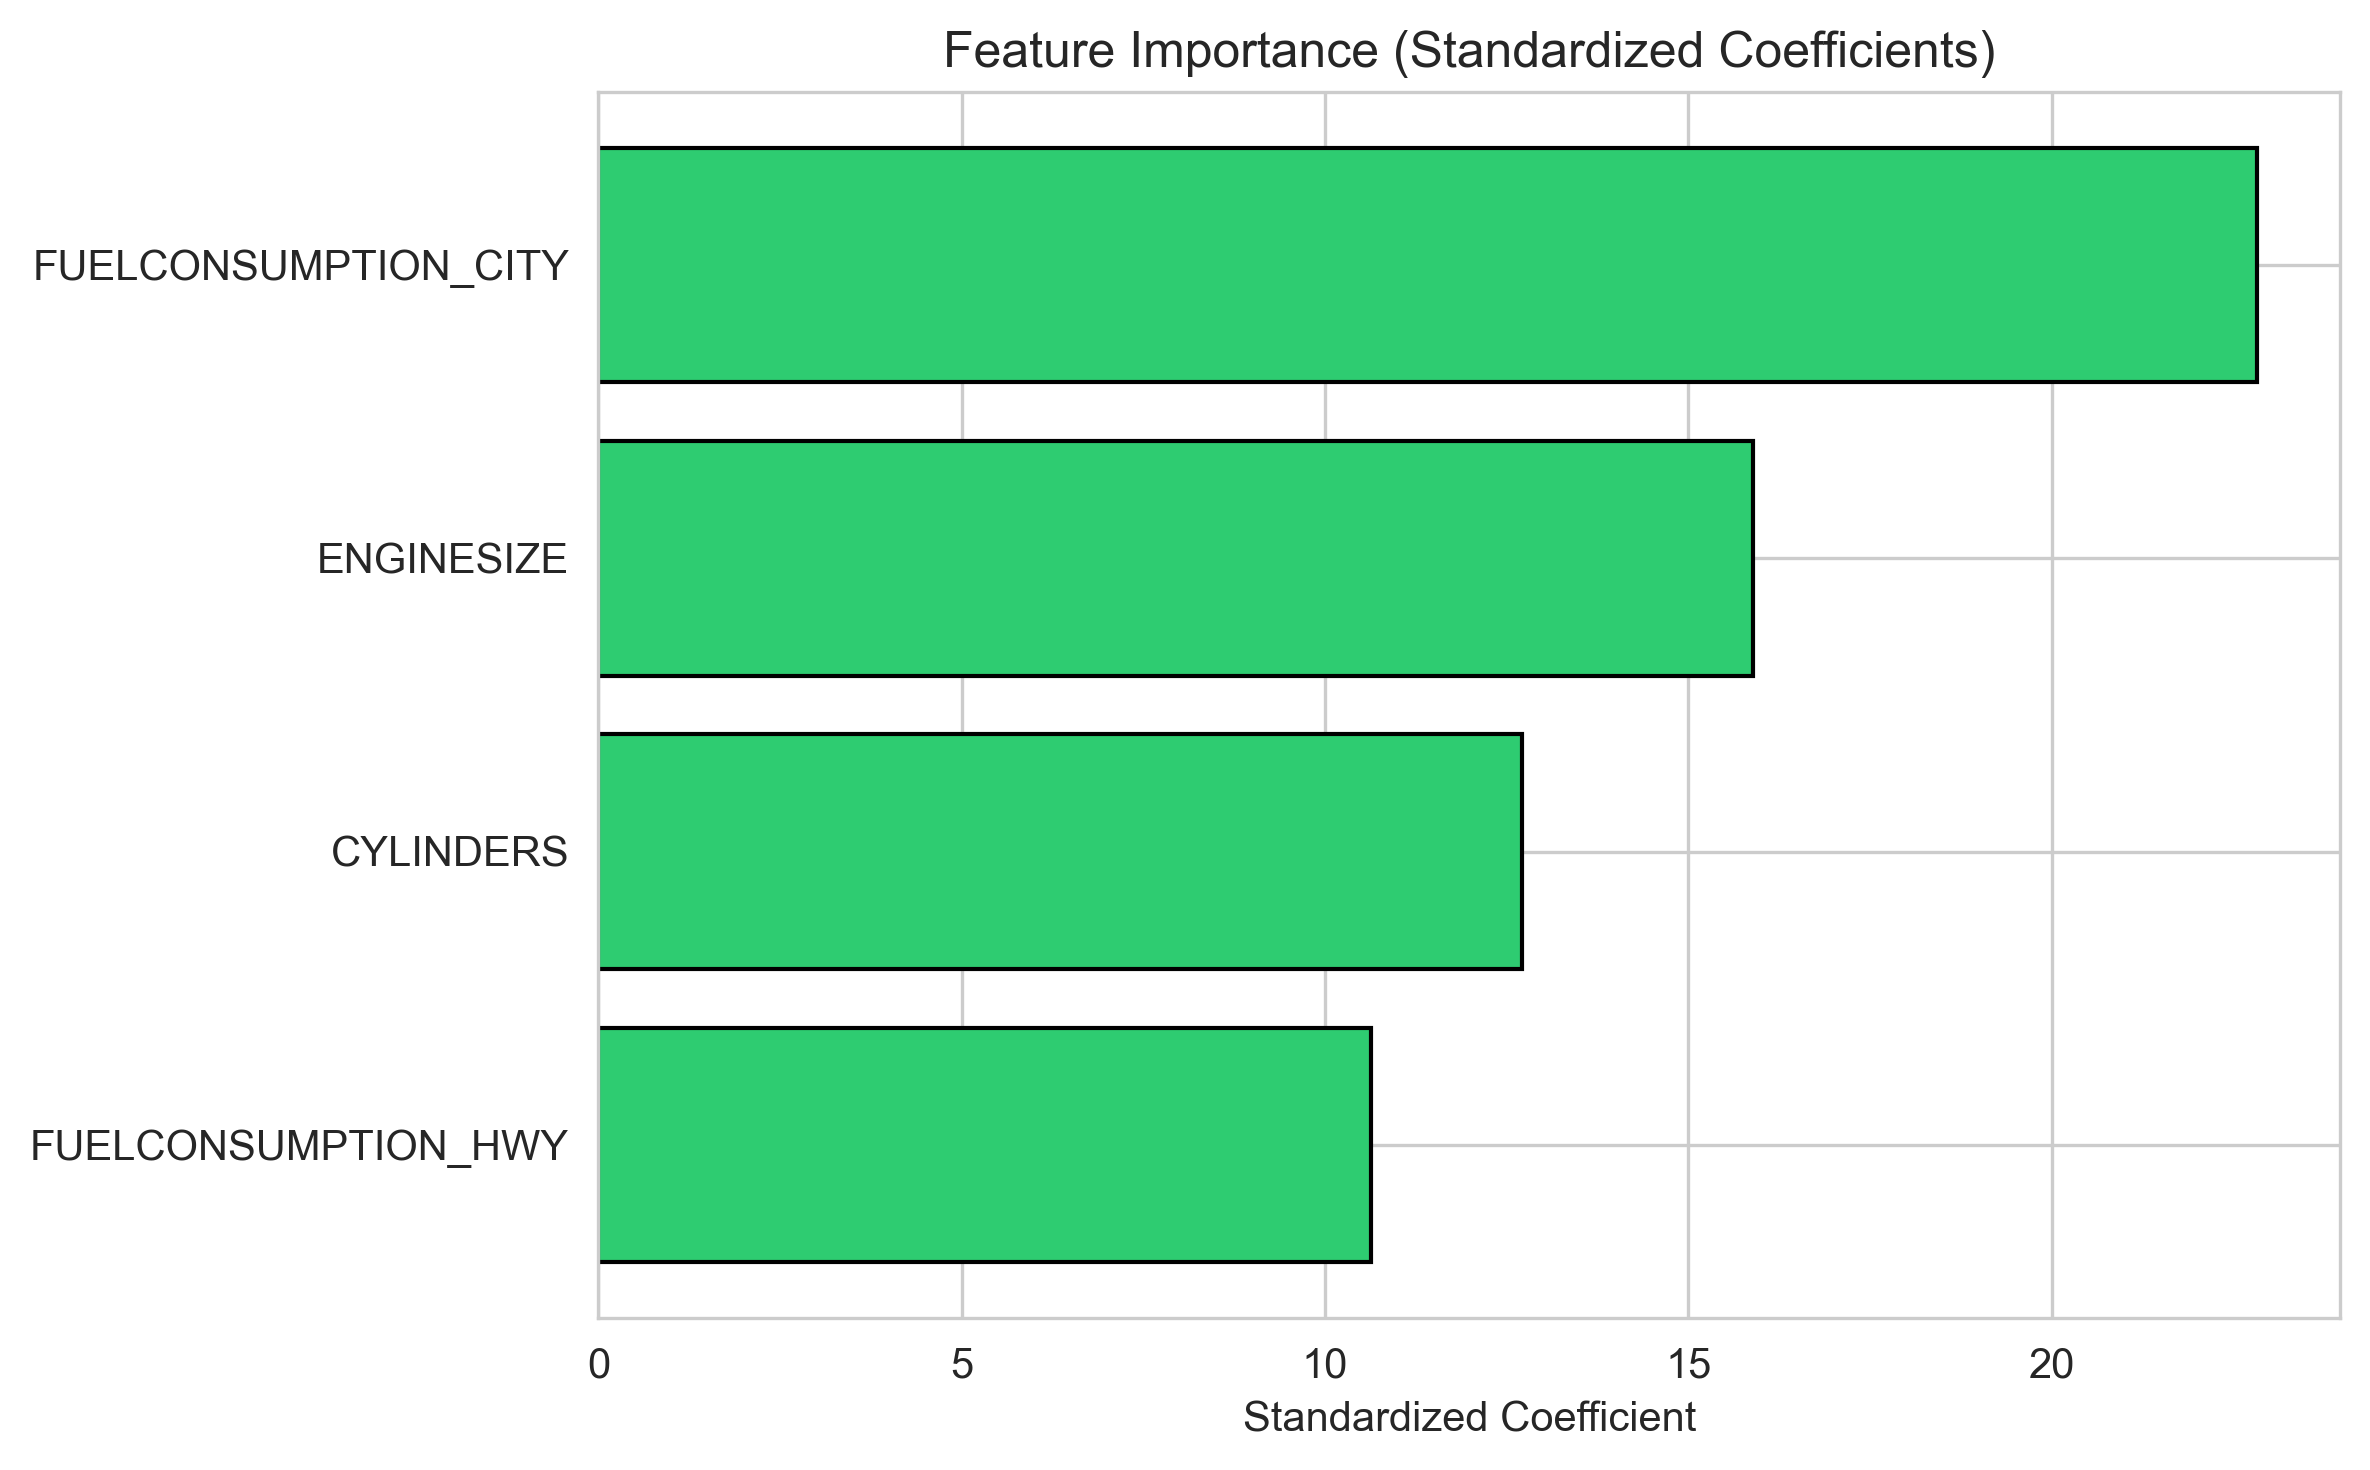

Standardized coefficients show the impact of each feature in standard deviation units.
Larger absolute values = more important features.


In [10]:
# Scale features and retrain to get standardized coefficients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_m)
X_test_scaled = scaler.transform(X_test_m)

scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train_m)

# Plot standardized coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Standardized Coefficient': scaled_model.coef_
}).sort_values('Standardized Coefficient', key=abs, ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Standardized Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Standardized Coefficient'], color=colors, edgecolor='black')
plt.xlabel('Standardized Coefficient')
plt.title('Feature Importance (Standardized Coefficients)')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Standardized coefficients show the impact of each feature in standard deviation units.')
print('Larger absolute values = more important features.')

### Discussion Questions (Part 4)

1. Which feature has the **largest** standardized coefficient? Is this what you expected?
2. Why might `FUELCONSUMPTION_CITY` and `FUELCONSUMPTION_HWY` have different coefficient signs or magnitudes?
3. Does adding more features always improve the model? What could go wrong?

---
## Part 5: Your Turn -- Find the Best Feature Combination

Experiment with different feature subsets to find the combination that gives the best R-squared on the test set.

**Available numeric features:**
- `ENGINESIZE`
- `CYLINDERS`
- `FUELCONSUMPTION_CITY`
- `FUELCONSUMPTION_HWY`
- `FUELCONSUMPTION_COMB`
- `FUELCONSUMPTION_COMB_MPG`

**Rules:**
- Use at least 2 and at most 5 features
- Use `random_state=42` and `test_size=0.2`
- Report R-squared and RMSE for each combination you try

In [11]:
# TODO: Try different feature combinations
# Example structure:

# my_features = ['ENGINESIZE', 'CYLINDERS', '...']  # <-- change these
# X_my = fuel_df[my_features]
# y = fuel_df['CO2EMISSIONS']

# X_tr, X_te, y_tr, y_te = train_test_split(X_my, y, test_size=0.2, random_state=42)

# my_model = LinearRegression()
# my_model.fit(X_tr, y_tr)
# y_pred = my_model.predict(X_te)

# print(f'Features: {my_features}')
# print(f'R-squared: {r2_score(y_te, y_pred):.4f}')
# print(f'RMSE: {np.sqrt(mean_squared_error(y_te, y_pred)):.2f}')

In [12]:
# TODO: Try another combination


In [13]:
# TODO: Try a third combination


### Bonus: Automated Feature Comparison

Run the cell below to systematically compare common feature combinations.

In [14]:
# Automated comparison of feature combinations
from itertools import combinations

all_features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY',
                'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
                'FUELCONSUMPTION_COMB_MPG']

results = []

# Try all combinations of 2 to 5 features
for n in range(2, 6):
    for combo in combinations(all_features, n):
        X_c = fuel_df[list(combo)]
        y_c = fuel_df['CO2EMISSIONS']
        X_tr, X_te, y_tr, y_te = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

        m = LinearRegression()
        m.fit(X_tr, y_tr)
        y_p = m.predict(X_te)

        results.append({
            'Features': ', '.join(combo),
            'Num_Features': n,
            'R2': r2_score(y_te, y_p),
            'RMSE': np.sqrt(mean_squared_error(y_te, y_p))
        })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)

print('=== TOP 10 FEATURE COMBINATIONS ===')
print(results_df.head(10).to_string(index=False))

print(f'\n=== WORST 5 FEATURE COMBINATIONS ===')
print(results_df.tail(5).to_string(index=False))

=== TOP 10 FEATURE COMBINATIONS ===
                                                                                            Features  Num_Features       R2      RMSE
                                ENGINESIZE, CYLINDERS, FUELCONSUMPTION_HWY, FUELCONSUMPTION_COMB_MPG             4 0.903547 19.970727
          ENGINESIZE, CYLINDERS, FUELCONSUMPTION_HWY, FUELCONSUMPTION_COMB, FUELCONSUMPTION_COMB_MPG             5 0.903496 19.976004
          ENGINESIZE, CYLINDERS, FUELCONSUMPTION_CITY, FUELCONSUMPTION_HWY, FUELCONSUMPTION_COMB_MPG             5 0.903485 19.977061
         ENGINESIZE, CYLINDERS, FUELCONSUMPTION_CITY, FUELCONSUMPTION_COMB, FUELCONSUMPTION_COMB_MPG             5 0.903481 19.977549
                               ENGINESIZE, CYLINDERS, FUELCONSUMPTION_COMB, FUELCONSUMPTION_COMB_MPG             4 0.902273 20.102144
                      CYLINDERS, FUELCONSUMPTION_HWY, FUELCONSUMPTION_COMB, FUELCONSUMPTION_COMB_MPG             4 0.900695 20.263807
                      CYLI

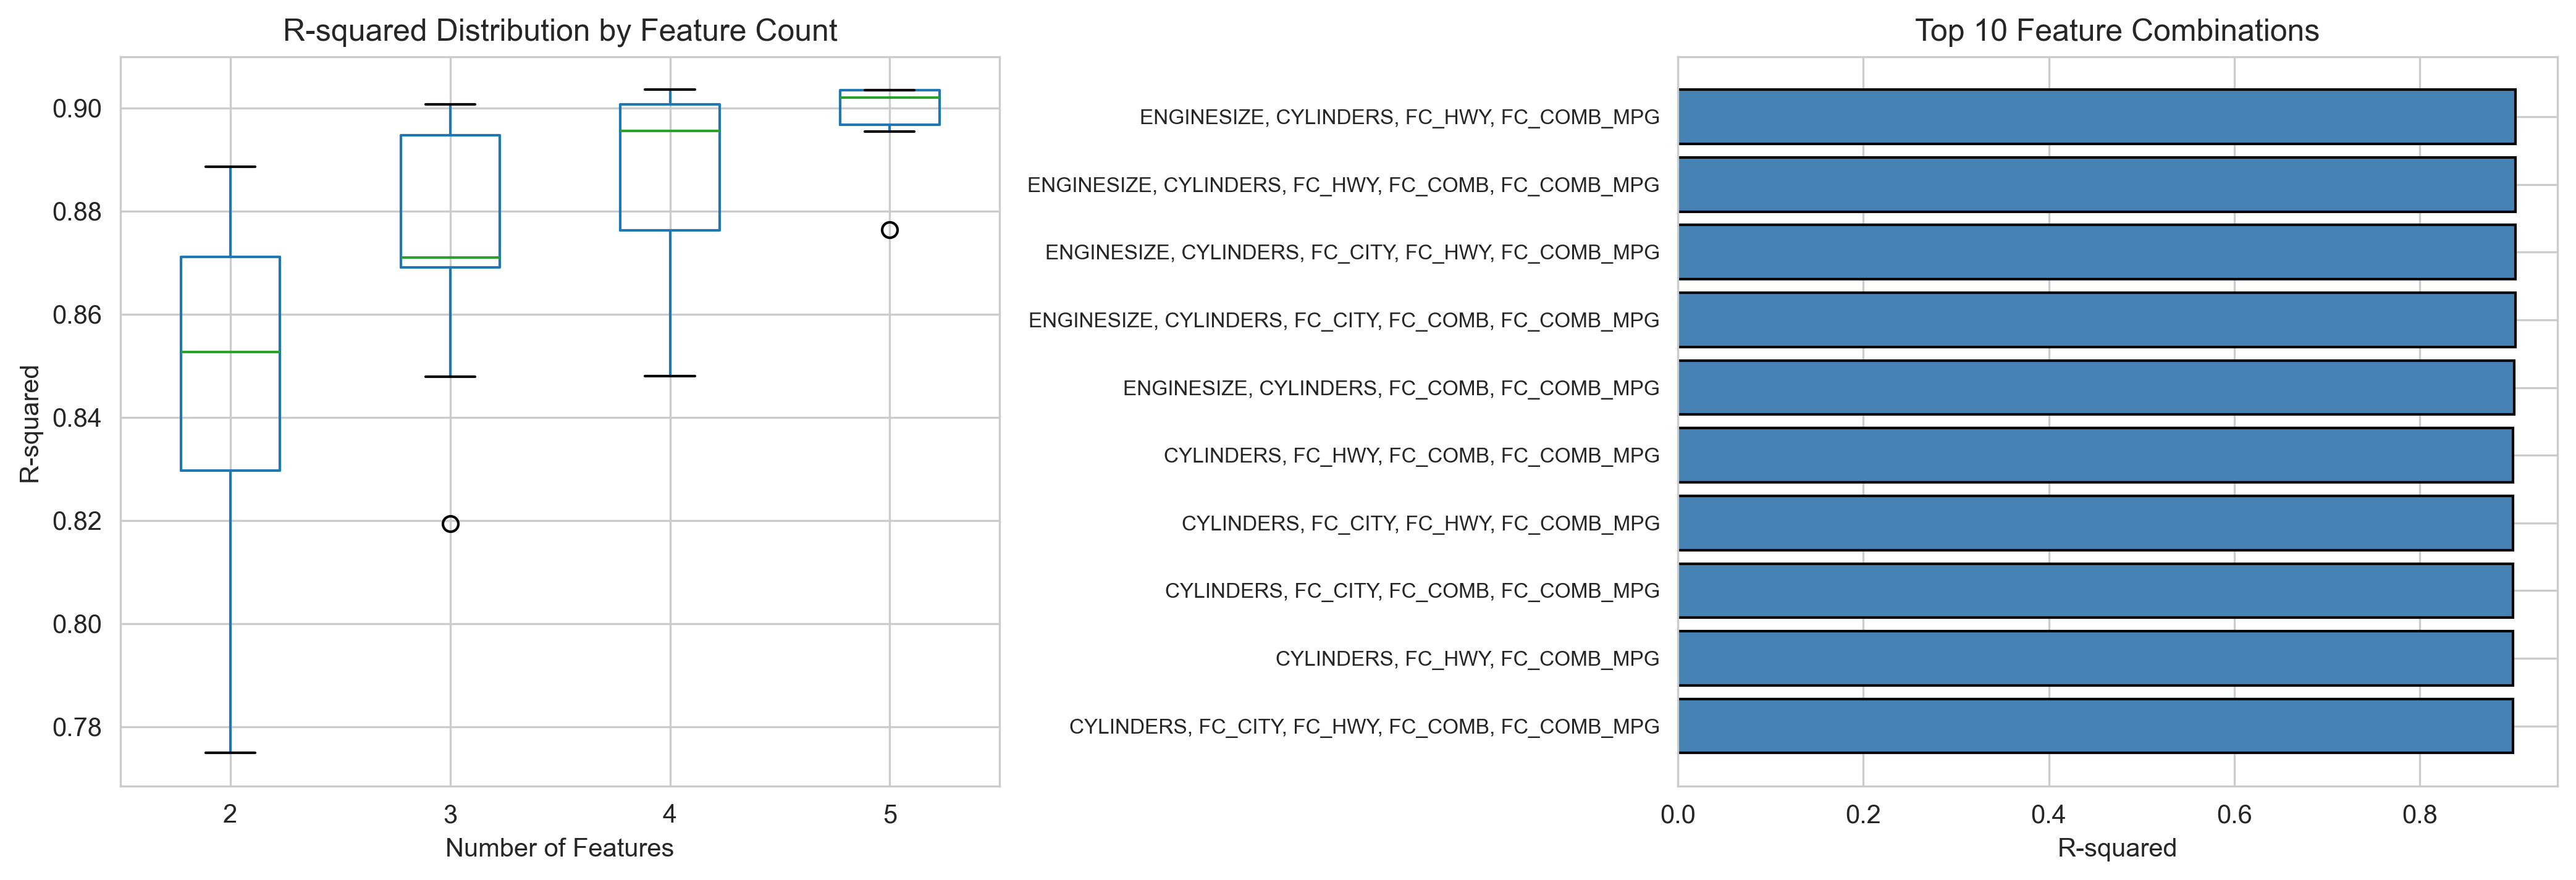

Key insight: More features do not always mean better performance.
Some 2-feature combos can outperform 4 or 5 feature combos!


In [15]:
# Visualize: R2 by number of features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of R2 by number of features
results_df.boxplot(column='R2', by='Num_Features', ax=axes[0])
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('R-squared')
axes[0].set_title('R-squared Distribution by Feature Count')
plt.sca(axes[0])
plt.title('R-squared Distribution by Feature Count')

# Top 10 combinations bar chart
top10 = results_df.head(10).copy()
top10['short_label'] = top10['Features'].apply(lambda x: x.replace('FUELCONSUMPTION_', 'FC_'))
axes[1].barh(range(len(top10)), top10['R2'], color='steelblue', edgecolor='black')
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10['short_label'], fontsize=8)
axes[1].set_xlabel('R-squared')
axes[1].set_title('Top 10 Feature Combinations')
axes[1].invert_yaxis()

plt.suptitle('')
plt.tight_layout()
plt.show()

print('Key insight: More features do not always mean better performance.')
print('Some 2-feature combos can outperform 4 or 5 feature combos!')

---
## Reflection Questions

Answer these in your own words:

1. **What was the best feature combination you found?** How much better was it than the single-feature baseline?

2. **Why don't all features contribute equally?** What makes some features more useful than others?

3. **Multicollinearity:** Some features (e.g., `FUELCONSUMPTION_CITY` and `FUELCONSUMPTION_COMB`) are highly correlated with each other. What problems might this cause in a regression model?

4. **Practical interpretation:** If you were advising a car manufacturer on how to reduce CO2 emissions, which features (vehicle characteristics) would you focus on based on your model?

---
## Summary

| Concept | What You Learned |
|---------|------------------|
| **Multiple regression** | Using several features often improves predictions over a single feature |
| **Feature correlation** | Highly correlated features may be redundant (multicollinearity) |
| **Feature scaling** | Standardizing features allows fair comparison of coefficients |
| **Feature selection** | More features is not always better -- choose features thoughtfully |
| **Model comparison** | Always compare against a baseline to measure improvement |